Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.1502
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1457
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1414
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1372
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1333
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1294
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1257
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1222
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1188
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1155
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1123
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1093
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1064
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1036
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.1009
Epoch 16/200
1/1 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


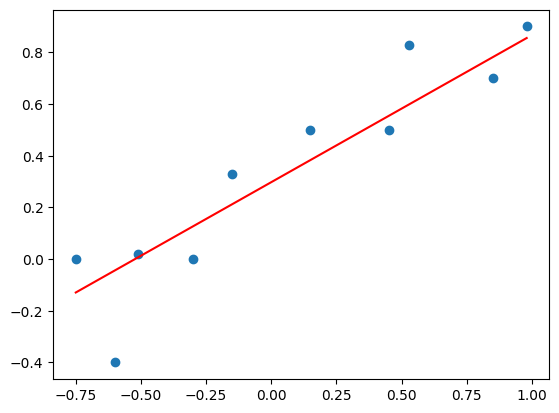

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
 3 의 예상 값은 2.00 입니다.


/tmp/ipykernel_1792/1451791289.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(" %.f 의 예상 값은 %.02f 입니다."%(guess, prediction))


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# linreg.html 사이트에 있는 10개 점 데이터로 교체
x = np.array([-0.75, -0.6, -0.51, -0.3, -0.15, 0.15, 0.45, 0.53, 0.85, 0.98])
y = np.array([ 0.00, -0.4,  0.02,  0.0,  0.33, 0.50, 0.50, 0.83, 0.70, 0.90])

model = Sequential()
model.add(Dense(1, input_dim=1, activation='linear'))

model.compile(optimizer='sgd', loss='mse')
model.fit(x, y, epochs=200)

plt.scatter(x, y)
plt.plot(x, model.predict(x), 'r')
plt.show()

# x = 3 에 대한 예상값은 ?
guess = 3
prediction = model.predict(np.array([guess]))
print(" %.f 의 예상 값은 %.02f 입니다."%(guess, prediction))

해당 코드로 3번 실행한 결과 다읔과 같이 예측값이 나왔다

| 실행 회차 | x=3 예측값 |
|---|---|
| 1회 | 0.7 |
| 2회 | 1.06 |
| 3회 | 2 |

해당 값이 변하는 이유를 설명하자면

Dense 레이어의 가중치(w)와 편향(b)은 학습을 시작하기 전 무작위  값으로 초기화된다. 경사하강법은 이 무작위 시작점에서 손실이 줄어드는 방향으로 조금씩 이동하는데, 시작점이 다르면 200번의 반복만으로는 완전히 동일한 최적점에 도달하지 못하고 서로 다른 지점에서 멈추게 된다. 특히 x=3은 학습에 사용한 데이터 범위(-0.75~0.98)를 크게 벗어난 값이므로, 학습된 직선의 기울기가 조금만 달라져도 그 차이가 외삽 구간에서 크게 증폭되어 예측값의 차이가 더욱 두드러지게 나타난다.

만약 이를 매번 동일하게 만들고 싶다면 `np.random.seed(42)`와 `tf.random.set_seed(42)`로 난수 시드를 고정하면 된다.